# CST3133 Coursework Part 2 - IMDb Sentiment Analysis



## 0. Colab Setup

The notebook is organised in stages so that the preprocessing workflow is presented first, followed by the modelling stage. The setup cell below installs the core packages required to run the notebook in Google Colab.


In [ ]:
!pip -q install tensorflow scikit-learn seaborn

In [ ]:
import os
import re
import zipfile
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 1.2.1 Text Dataset Selection and Preprocessing

### 1.2.1.1 Load the dataset

The selected dataset is the **IMDb Dataset of 50K Movie Reviews**, a widely used benchmark for binary sentiment classification. It is suitable for this task because it contains a large volume of labelled reviews, balanced sentiment classes, and text data of sufficient length and variability to support sequence-based modelling.

This notebook expects `IMDB Dataset.csv` to be available in the current Colab working directory. If necessary, the file can be uploaded manually before proceeding.


In [ ]:
from google.colab import files

DATASET_PATH = 'IMDB Dataset.csv'

if not os.path.exists(DATASET_PATH):
    print('IMDB Dataset.csv not found. Please upload it now.')
    files.upload()

df = pd.read_csv(DATASET_PATH)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df.isna().sum())
print('\nClass distribution:')
print(df['sentiment'].value_counts())

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


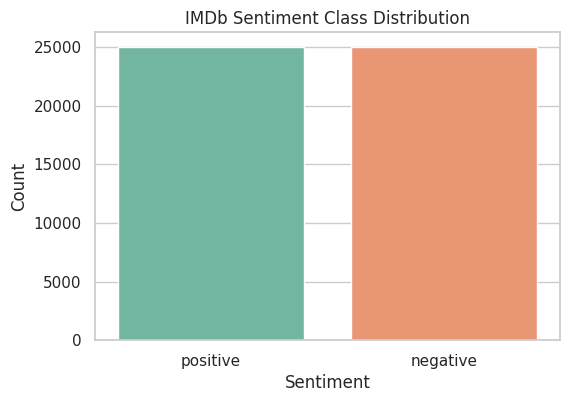

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='Set2', ax=ax)
ax.set_title('IMDb Sentiment Class Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
plt.show()

### 1.2.1.2 Text cleaning and task-aware preprocessing



In [ ]:
CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am"
}


def expand_contractions(text):
    text = str(text)
    for pattern, replacement in CONTRACTIONS.items():
        text = text.replace(pattern, replacement)
    return text


def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = expand_contractions(text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df = df.dropna(subset=['review', 'sentiment']).copy()
duplicate_rows = df.duplicated(subset=['review', 'sentiment']).sum()
df = df.drop_duplicates(subset=['review', 'sentiment']).copy()
df['clean_review'] = df['review'].apply(clean_text)
df = df[df['clean_review'].str.len() > 0].copy()
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

print('Shape after cleaning:', df.shape)
print('Duplicate review rows removed:', duplicate_rows)
print('Empty cleaned reviews:', (df['clean_review'].str.len() == 0).sum())
df[['review', 'clean_review', 'sentiment', 'label']].head(3)


Shape after cleaning: (49582, 4)
Duplicate review rows removed: 418
Empty cleaned reviews: 0


,review,clean_review,sentiment,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive,1


In [ ]:
print('Sentiment distribution after cleaning:')
print(df['sentiment'].value_counts())

sample_preview = df[['review', 'clean_review', 'sentiment']].sample(3, random_state=SEED)
sample_preview


Sentiment distribution after cleaning:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


,review,clean_review,sentiment
29171,"""Soul Plane"" is a horrible attempt at comedy t...",soul plane is a horrible attempt at comedy tha...,negative
43589,Guest from the Future tells a fascinating stor...,guest from the future tells a fascinating stor...,positive
38712,"""National Treasure"" (2004) is a thoroughly mis...",national treasure is a thoroughly misguided ho...,negative


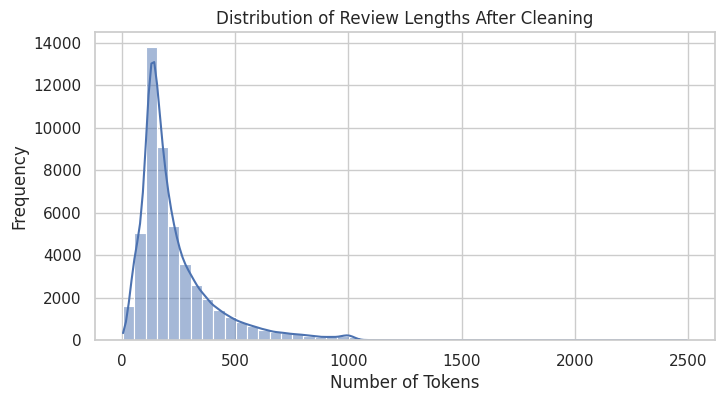

,clean_review
count,49582.000000
mean,234.244282
std,173.629498
min,6.000000
50%,176.000000
75%,284.000000
90%,457.000000
95%,598.950000
99%,916.000000
max,2494.000000


In [ ]:
review_lengths = df['clean_review'].str.split().apply(len)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(review_lengths, bins=50, kde=True, ax=ax)
ax.set_title('Distribution of Review Lengths After Cleaning')
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('Frequency')
plt.show()

review_lengths.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


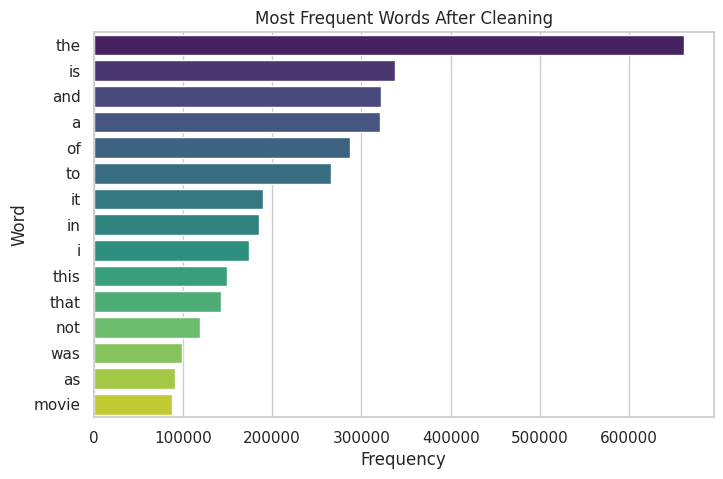

,word,count
0,the,661758
1,is,337573
2,and,322096
3,a,320811
4,of,287344
5,to,266109
6,it,189442
7,in,185423
8,i,174136
9,this,149780


In [ ]:
from collections import Counter

top_words = Counter(' '.join(df['clean_review']).split()).most_common(15)
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top_words_df, y='word', x='count', palette='viridis', ax=ax)
ax.set_title('Most Frequent Words After Cleaning')
ax.set_xlabel('Frequency')
ax.set_ylabel('Word')
plt.show()

top_words_df


### Train, validation, and test split



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],
    df['label'],
    test_size=0.2,
    random_state=SEED,
    stratify=df['label']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

split_summary = pd.DataFrame({
    'subset': ['Train', 'Validation', 'Test'],
    'size': [len(X_train), len(X_val), len(X_test)],
    'positive': [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    'negative': [
        int((y_train == 0).sum()),
        int((y_val == 0).sum()),
        int((y_test == 0).sum())
    ]
})

split_summary


,subset,size,positive,negative
0,Train,31732,15926,15806
1,Validation,7933,3981,3952
2,Test,9917,4977,4940


### Tokenisation and padding



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 220
EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('Vocabulary size learned:', min(MAX_WORDS, len(tokenizer.word_index) + 1))
print('Padded train shape:', X_train_pad.shape)
print('Padded validation shape:', X_val_pad.shape)
print('Padded test shape:', X_test_pad.shape)


Vocabulary size learned: 20000
Padded train shape: (31732, 220)
Padded validation shape: (7933, 220)
Padded test shape: (9917, 220)


In [ ]:
sample_tokens = pd.DataFrame({
    'clean_review': X_train.iloc[:3].values,
    'sequence': X_train_seq[:3]
})

sample_tokens


,clean_review,sequence
0,joseph l mankiewicz is not remembered by most ...,"[2305, 1253, 17862, 3, 13, 1999, 32, 90, 493, ..."
1,when dubbed into another language let is face ...,"[51, 2230, 84, 154, 1068, 273, 3, 379, 8, 1107..."
2,it is a good movie if you plan to watch lots o...,"[8, 3, 5, 50, 16, 45, 21, 1327, 7, 104, 702, 6..."


### Pre-trained embeddings




In [ ]:
glove_zip_path = tf.keras.utils.get_file(
    'glove.6B.zip',
    origin='https://nlp.stanford.edu/data/glove.6B.zip',
    extract=False
)

glove_dir = os.path.join(os.path.dirname(glove_zip_path), 'glove.6B')
os.makedirs(glove_dir, exist_ok=True)

glove_txt_path = os.path.join(glove_dir, 'glove.6B.100d.txt')

if not os.path.exists(glove_txt_path):
    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extractall(glove_dir)

print('GloVe file ready at:', glove_txt_path)


GloVe file ready at: /root/.keras/datasets/glove.6B/glove.6B.100d.txt


In [ ]:
embeddings_index = {}
with open(glove_txt_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print('Loaded embeddings:', len(embeddings_index))


Loaded embeddings: 400000


In [ ]:
num_words = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

hits = 0
misses = 0

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_WORDS:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[idx] = embedding_vector
        hits += 1
    else:
        misses += 1

embedding_summary = pd.DataFrame({
    'measure': ['Embedding matrix shape', 'Words with GloVe vectors', 'Words without GloVe vectors'],
    'value': [str(embedding_matrix.shape), hits, misses]
})

embedding_summary


,measure,value
0,Embedding matrix shape,"(20000, 100)"
1,Words with GloVe vectors,19889
2,Words without GloVe vectors,110


## 1.2.2 Deep Learning Model Implementation




In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


### Baseline LSTM model



In [ ]:
lstm_model = Sequential([
    Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])

lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

lstm_model.build((None, MAX_LEN))
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 220, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,042,305 (7.79 MB)

 Trainable params: 2,042,305 (7.79 MB)

 Non-trainable params: 0 (0.00 B)

### Training the LSTM model



In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
)

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 129s 255ms/step - accuracy: 0.5318 - loss: 0.6946 - val_accuracy: 0.5133 - val_loss: 0.6920
Epoch 2/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 121s 245ms/step - accuracy: 0.5267 - loss: 0.6925 - val_accuracy: 0.5399 - val_loss: 0.6813
Epoch 3/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 122s 246ms/step - accuracy: 0.6016 - loss: 0.6472 - val_accuracy: 0.8345 - val_loss: 0.4597
Epoch 4/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 121s 243ms/step - accuracy: 0.8640 - loss: 0.3513 - val_accuracy: 0.8680 - val_loss: 0.3257
Epoch 5/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 143s 246ms/step - accuracy: 0.9160 - loss: 0.2365 - val_accuracy: 0.8748 - val_loss: 0.3020
Epoch 6/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 123s 248ms/step - accuracy: 0.9462 - loss: 0.1708 - val_accuracy: 0.8700 - val_loss: 0.3467
Epoch 7/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 121s 243ms/step - accuracy: 0.9639 - loss: 0.1282 - val_accuracy: 0.8709 - val_loss: 0.3838


### BiLSTM model



In [ ]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([
    Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,
    ),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

bilstm_model.build((None, MAX_LEN))
bilstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 220, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,084,609 (7.95 MB)

 Trainable params: 2,084,609 (7.95 MB)

 Non-trainable params: 0 (0.00 B)

### Training the BiLSTM model

1.   List item
2.   List item





In [ ]:
early_stopping_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping_bilstm],
    verbose=1,
)


Epoch 1/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 230s 458ms/step - accuracy: 0.6433 - loss: 0.6313 - val_accuracy: 0.7614 - val_loss: 0.5448
Epoch 2/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 227s 458ms/step - accuracy: 0.7773 - loss: 0.4691 - val_accuracy: 0.8255 - val_loss: 0.3924
Epoch 3/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 259s 452ms/step - accuracy: 0.8962 - loss: 0.2690 - val_accuracy: 0.8748 - val_loss: 0.3042
Epoch 4/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 226s 455ms/step - accuracy: 0.9346 - loss: 0.1864 - val_accuracy: 0.8773 - val_loss: 0.3133
Epoch 5/8
496/496 ━━━━━━━━━━━━━━━━━━━━ 261s 453ms/step - accuracy: 0.9591 - loss: 0.1280 - val_accuracy: 0.8742 - val_loss: 0.3508


## 1.2.3 Evaluation and Insights




In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


### Helper functions for evaluation



In [ ]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Training accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
    axes[0].set_title(f'{model_name} Accuracy Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Training loss')
    axes[1].plot(history.history['val_loss'], label='Validation loss')
    axes[1].set_title(f'{model_name} Loss Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred_prob = model.predict(X_test_data, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype('int32').flatten()

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print(f'{model_name} Accuracy:  {accuracy:.4f}')
    print(f'{model_name} Precision: {precision:.4f}')
    print(f'{model_name} Recall:    {recall:.4f}')
    print(f'{model_name} F1-score:  {f1:.4f}')
    print('\nClassification report:')
    print(classification_report(y_test_data, y_pred, target_names=['Negative', 'Positive']))

    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
    )
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
    }


### Learning curves



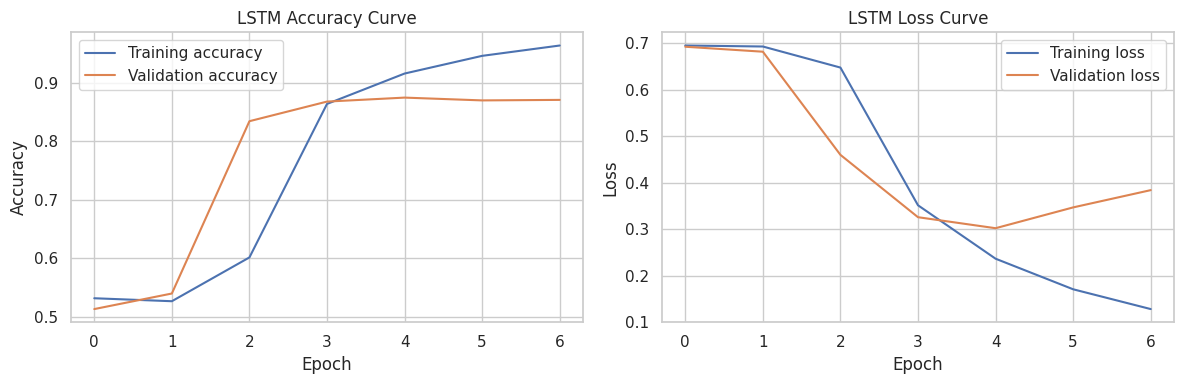

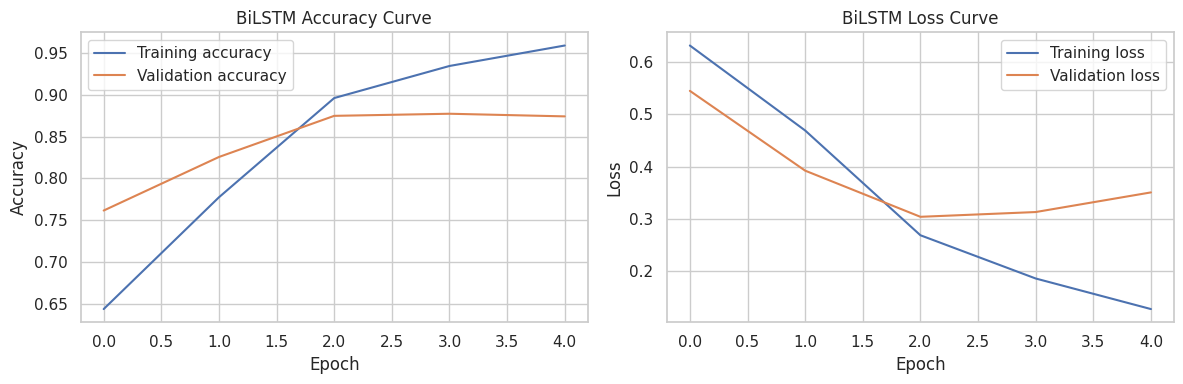

In [ ]:
plot_training_history(lstm_history, 'LSTM')
plot_training_history(bilstm_history, 'BiLSTM')


### Test-set evaluation


LSTM Accuracy:  0.8750
LSTM Precision: 0.8747
LSTM Recall:    0.8764
LSTM F1-score:  0.8756

Classification report:
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87      4940
    Positive       0.87      0.88      0.88      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



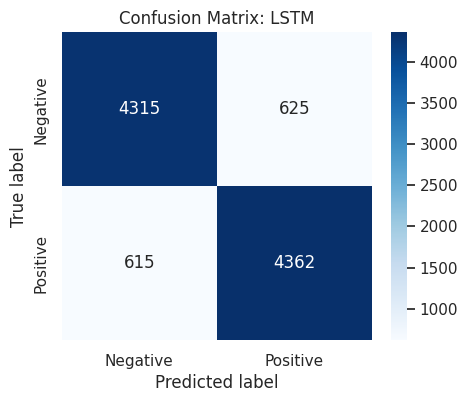

BiLSTM Accuracy:  0.8789
BiLSTM Precision: 0.8525
BiLSTM Recall:    0.9174
BiLSTM F1-score:  0.8838

Classification report:
              precision    recall  f1-score   support

    Negative       0.91      0.84      0.87      4940
    Positive       0.85      0.92      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



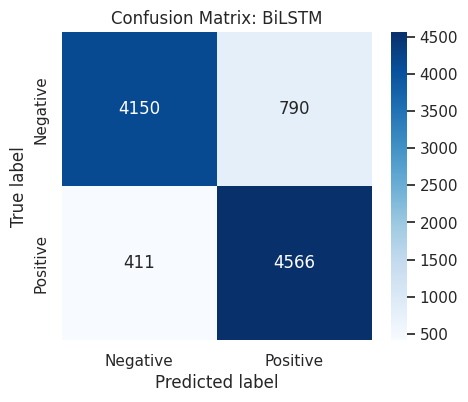

In [ ]:
lstm_results = evaluate_model(lstm_model, X_test_pad, y_test, 'LSTM')
bilstm_results = evaluate_model(bilstm_model, X_test_pad, y_test, 'BiLSTM')


### LSTM and BiLSTM comparison




In [ ]:
recurrent_results_df = pd.DataFrame([lstm_results, bilstm_results])
recurrent_results_df = recurrent_results_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)
recurrent_results_df


,Model,Accuracy,Precision,Recall,F1-score
0,BiLSTM,0.878895,0.852502,0.917420,0.883770
1,LSTM,0.874962,0.874674,0.876432,0.875552


## Small Hyperparameter Tuning

In [ ]:
tuning_configs = [
    {'name': 'baseline', 'learning_rate': 1e-3, 'dropout_rate': 0.5, 'batch_size': 64},
    {'name': 'smaller_lr', 'learning_rate': 5e-4, 'dropout_rate': 0.5, 'batch_size': 64},
    {'name': 'smaller_batch', 'learning_rate': 1e-3, 'dropout_rate': 0.5, 'batch_size': 32},
    {'name': 'lower_dropout', 'learning_rate': 1e-3, 'dropout_rate': 0.3, 'batch_size': 64},
]

tuning_results = []

for config in tuning_configs:
    tuned_model = Sequential([
        Embedding(
            input_dim=num_words,
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True,
        ),
        LSTM(64),
        Dropout(config['dropout_rate']),
        Dense(1, activation='sigmoid'),
    ])

    tuned_model.compile(
        optimizer=Adam(learning_rate=config['learning_rate']),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    tuned_history = tuned_model.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=4,
        batch_size=config['batch_size'],
        callbacks=[EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)],
        verbose=0,
    )

    best_val_accuracy = max(tuned_history.history['val_accuracy'])
    best_val_loss = min(tuned_history.history['val_loss'])

    tuning_results.append({
        'Configuration': config['name'],
        'Learning rate': config['learning_rate'],
        'Dropout': config['dropout_rate'],
        'Batch size': config['batch_size'],
        'Best val_accuracy': best_val_accuracy,
        'Best val_loss': best_val_loss,
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(by='Best val_accuracy', ascending=False).reset_index(drop=True)
tuning_results_df


,Configuration,Learning rate,Dropout,Batch size,Best val_accuracy,Best val_loss
0,lower_dropout,0.0010,0.3,64,0.880625,0.290263
1,smaller_batch,0.0010,0.5,32,0.868398,0.326493
2,baseline,0.0010,0.5,64,0.751292,0.563331
3,smaller_lr,0.0005,0.5,64,0.522375,0.691084
